# Primary Vertex check

Checking data generated with key4hep and Juraj considering the changes I suggest in [this PR](https://github.com/key4hep/CLDConfig/pull/74).

In [1]:
import uproot 
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator, FuncFormatter

import gc

from sklearn.metrics import roc_curve, auc, roc_auc_score
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm

%load_ext autoreload
%autoreload 2

In [2]:
from scipy.optimize import curve_fit

In [3]:
from cycler import cycler
import matplotlib

# Set the color cycle
# https://coolors.co/542344-f68e5f-e5e059-007ea7-98e2c6
plt.rc('axes', prop_cycle=cycler('color', ['#73b06f', '#e6701b', '#007090', '#e7298a', '#802392', '#ffad08', '#56b4e9']))
matplotlib.rcParams["font.family"] = "serif"
# Set font sizes
matplotlib.rcParams.update(
    {
        "font.size": 14,  # General font size
    }
)

In [4]:
base_path_CLD_v7 = "/eos/experiment/fcc/ee/datasets/CLD_fullsim_tagging_from_key4hep/CLD_v7/no_BS_constraint_in_PV_fit"

path_Huu = base_path_CLD_v7 + "Huu_0.root"  
path_Hdd = base_path_CLD_v7 + "Hdd_0.root"  
path_Hss = base_path_CLD_v7 + "Hss_0.root"  
path_Hbb = base_path_CLD_v7 + "Hbb_0.root"  
path_Hcc = base_path_CLD_v7 + "Hcc_0.root"  
path_Hgg = base_path_CLD_v7 + "Hgg_0.root"  
path_Htautau = base_path_CLD_v7 + "Htautau_0.root"  

In [5]:
def load_data(file_name, stop=3000, key='JetConstituentObservables;1'):
    file = uproot.open(file_name)
    tree = file[key]
    data = tree.arrays(library="np", entry_start=0, entry_stop=stop)
    return data

In [6]:
dic = {
    'Hgg': load_data(path_Hgg),
    'Huu': load_data(path_Huu),
    'Hdd': load_data(path_Hdd),
    'Hss': load_data(path_Hss),
    'Hcc': load_data(path_Hcc),
    'Hbb': load_data(path_Hbb),
    'Htautau': load_data(path_Htautau)
}

In [21]:

def plot_PV(dic, bins=50):
    keys = ['jet_PV_x', 'jet_PV_y', 'jet_PV_z']

    fig, axs = plt.subplots(1, 3, figsize=(20, 7))
    units = ["$\mu$m", "nm", "mm"]
    r = {
        "jet_PV_x": (-30, 30),
        "jet_PV_y": (-9000, 9000),
        "jet_PV_z": (-2, 2),
    }
    multipliers = {
        "jet_PV_x": 1e3,
        "jet_PV_y": 1e6,
        "jet_PV_z": 1,
    }
    xlabels = [r"$x$ ($\mu$m)", "$y$ (nm)", "$z$ (mm)"]

    for j, flavor in enumerate(dic.keys()):
        for i, key in enumerate(keys):
            data = dic[flavor][key] * multipliers[key]
            rms = np.sqrt(np.mean(data**2))
            # overflow bins
            d = np.clip(data, r[key][0], r[key][1])

            # plot histograms
            axs[i].hist(d, bins=bins, range=r[key], histtype="step", label="{} (RMS={:.2f} {})".format(flavor, rms, units[i]), density=True, linewidth=2)

            axs[i].set_xlabel(xlabels[i])
            axs[i].grid()
            axs[i].legend() #loc="lower left")
            axs[i].set_yscale("log")

    plt.show()


        

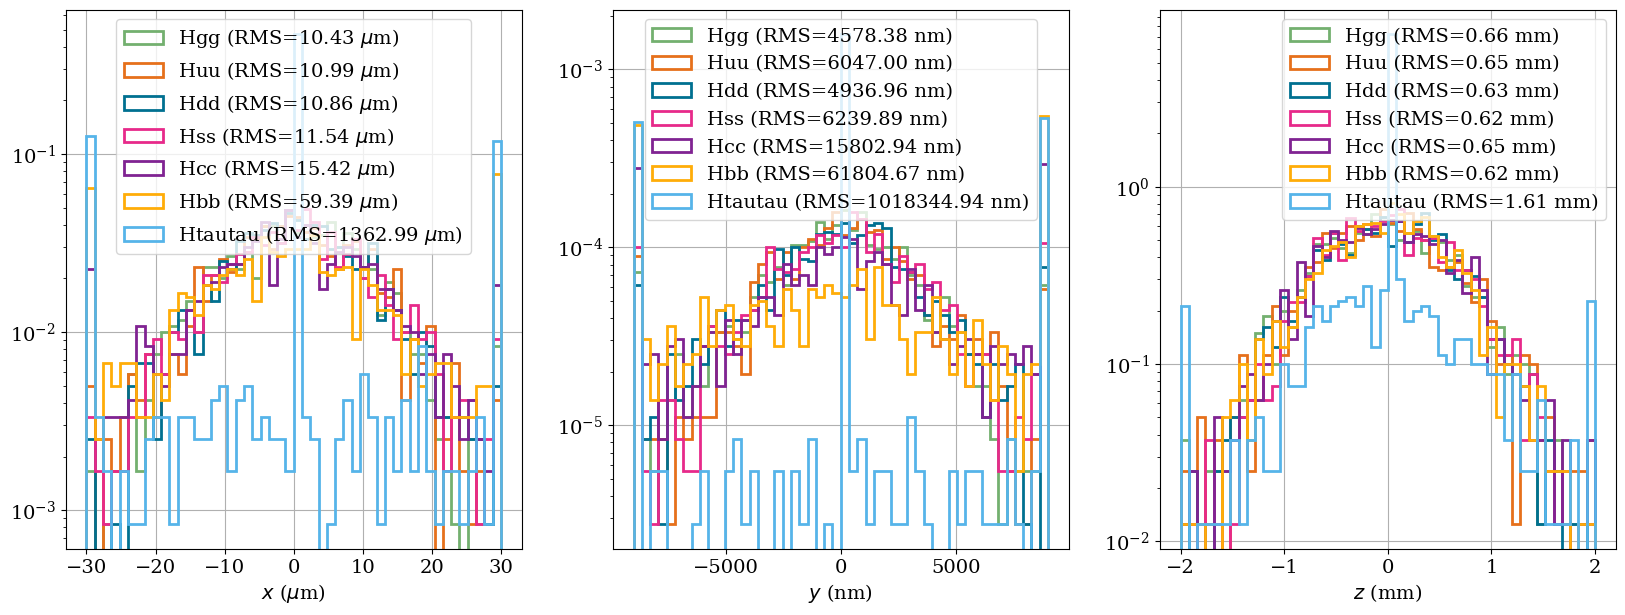

In [22]:
plot_PV(dic, bins=50)

In [9]:

def plot_PV_without_Htautau(dic, bins=50):
    keys = ['jet_PV_x', 'jet_PV_y', 'jet_PV_z']

    fig, axs = plt.subplots(1, 3, figsize=(20, 6))
    units = ["$\mu$m", "nm", "mm"]
    r = {
        "jet_PV_x": (-30, 30),
        "jet_PV_y": (-9000, 9000),
        "jet_PV_z": (-2, 2),
    }
    multipliers = {
        "jet_PV_x": 1e3,
        "jet_PV_y": 1e6,
        "jet_PV_z": 1,
    }
    xlabels = [r"$x$ ($\mu$m)", "$y$ (nm)", "$z$ (mm)"]

    for j, flavor in enumerate(dic.keys()):
        # skip Htautau
        if flavor == 'Htautau':
            continue
        for i, key in enumerate(keys):
            data = dic[flavor][key] * multipliers[key]
            rms = np.sqrt(np.mean(data**2))
            # overflow bins
            d = np.clip(data, r[key][0], r[key][1])

            # plot histograms
            axs[i].hist(d, bins=bins, range=r[key], histtype="step", label="{} (RMS={:.2f} {})".format(flavor, rms, units[i]), density=True, linewidth=2)

            axs[i].set_xlabel(xlabels[i])
            axs[i].grid(True)
            axs[i].legend()

    plt.show()


        

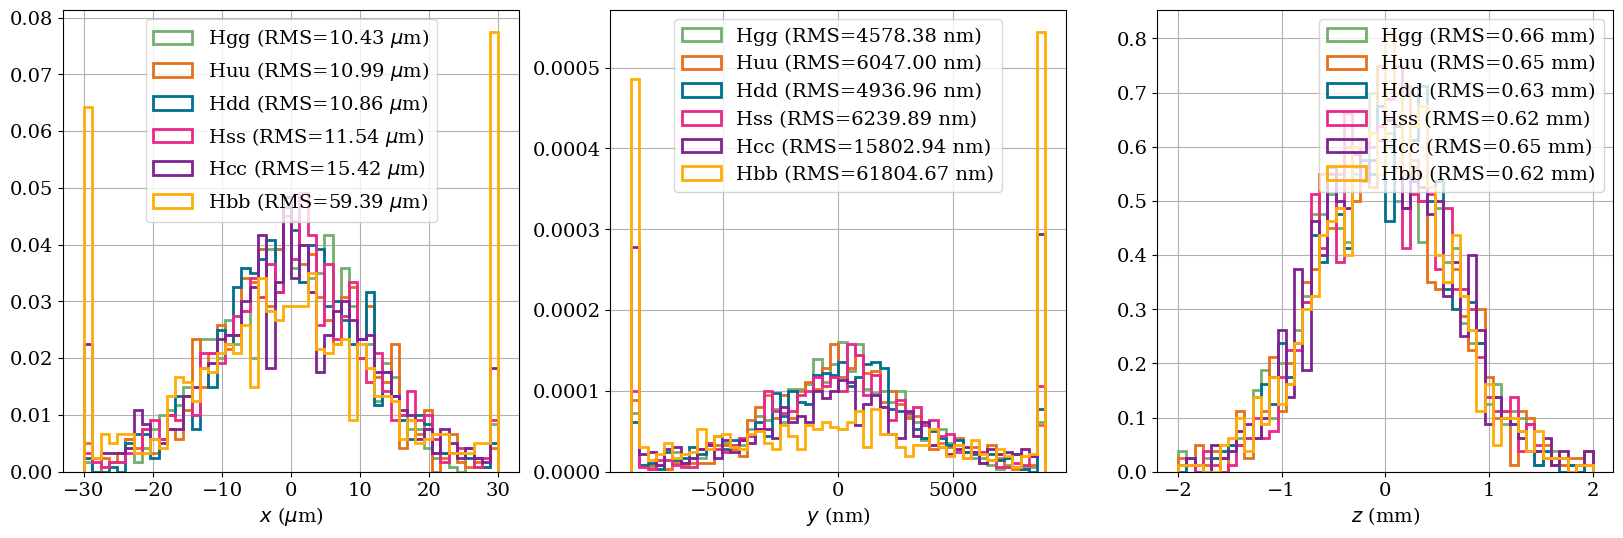

In [10]:
plot_PV_without_Htautau(dic, bins=50)